# Simulator Distributions

In [1]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt

## Definition of System Parameters

### Cost Parameters

In [2]:
cost_failure = 1200
cost_component = 100
cost_inspection = 100
cost_replacement = 1000

### Model Parameters

Define the parameters $\eta = 30*24 h$, one month, $\beta = 3$ for the components "Fail Age" given by a Weibull distribution.

Define the expiration age as $110\%$ of $\mu$ for the automatic mandatory component replacement, despite inspections. 

In [ ]:
eta = 30*24
beta = 3

expiration = 1.1*eta

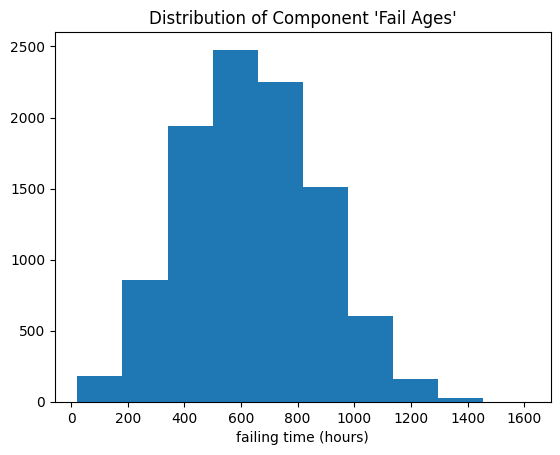

In [4]:
fail_ages = eta*np.random.weibull(beta, size=10000)

plt.hist(fail_ages)
plt.xlabel("failing time (hours)")
plt.title("Distribution of Component 'Fail Ages'")
plt.show()

### Inspection Schedule Parameters

Define the parameters $\mu = 7*24 h$, one week, $\sigma = 15\%$ of $ \mu$ for the time between inspections, given by a Normal distribution.

Also, when an inspection is required but not urgent, the time for said inspectin is scheduled following an Exponential distribution of parameter $\theta = 12h$

In [5]:
mu = 7*24
sigma = 0.15*mu

theta = 12

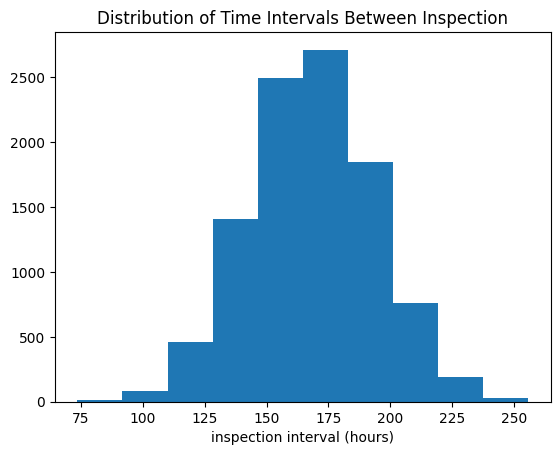

In [6]:
inspection_windows = np.random.normal(loc=mu, scale=sigma, size=10000)

plt.hist(inspection_windows)
plt.xlabel("inspection interval (hours)")
plt.title("Distribution of Time Intervals Between Inspection")
plt.show()

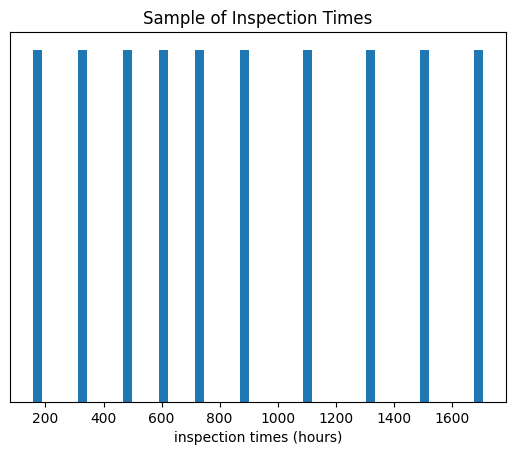

In [7]:
inspection_times = np.cumsum(inspection_windows)[:10]

plt.hist(inspection_times, bins=50)
plt.xlabel("inspection times (hours)")
plt.yticks([])
plt.title("Sample of Inspection Times")
plt.show()

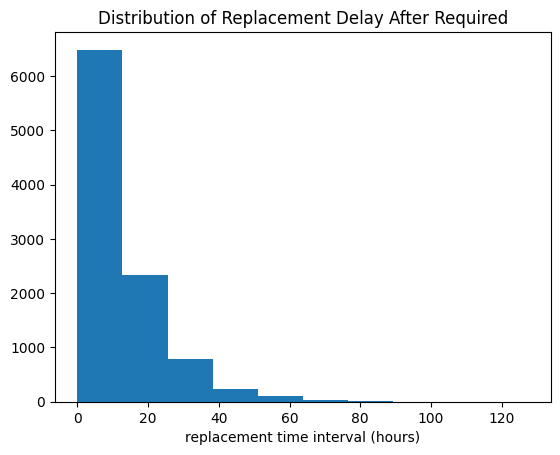

In [8]:
inspection_windows = np.random.exponential(theta, size=10000)

plt.hist(inspection_windows)
plt.xlabel("replacement time interval (hours)")
plt.title("Distribution of Replacement Delay After Required")
plt.show()

### Inspection Quality Parameters

The objective of an inspection is to check if a component is old, that can be seen as presenting wearing signals. Since the age of a component is known, but not exactly its distribution, we model this fenomenon as follows:
 * A measure of the age/wear of a component will be an estimation the CDF (Cumulated Density Function) if its fail age; if the pdf is close the 0 the component is new, and if it is close to 1, it almost centainly will present a pane
 * Since the inspection is not perfect, we consider a distribution around the exact CDF in question; this is done by considering a Beta distribution whose average is the exact CDF, $$p = Mean = CDF(component)$$ and variance given by $$Var = \alpha* Mean*(1-Mean),$$ where $0 < \alpha < 1$ is a quality measure, or Inspection Precision, this is due to a constraint of the Beta distribution that $Var < Mean*(1-Mean)$.
 * The parameters $a,b$ of the Beta distribution are finally given as follows, based on: $$a =  CDF* (CDF*(1-CDF)/VAR-1)$$ and $$b = (1-CDF)*(CDF*(1-CDF)/VAR-1).$$ See https://en.wikipedia.org/wiki/Beta_distribution#Mean_and_variance for clarification

In [ ]:
inspection_threshold = 0.5 # if p is bigger, then replace
inspection_deviation = 0.05 # alpha

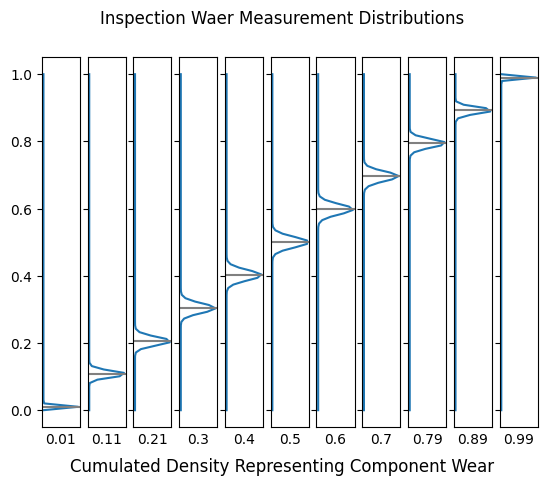

In [8]:
n = 11
fig, ax = plt.subplots(1, n, sharey=True)

cdfs = np.linspace(0.01,0.99,n)

sample = np.linspace(0,1,100)
for i in range(n):
    p = cdfs[i]

    var = inspection_deviation*p*(1-p)
    a = p * (p*(1-p)/var-1)
    b = (1-p)*(p*(1-p)/var-1)
    
    pdf = scp.stats.beta.pdf(sample, a, b)

    ax[i].plot(pdf, sample)
    ax[i].axhline(y=p, color="gray")
    ax[i].set_xlabel(p.round(2))
    ax[i].set_xticks([])

plt.suptitle("Inspection Waer Measurement Distributions")
fig.supxlabel("Cumulated Density Representing Component Wear")
plt.show()

### Fleet Evolution

We assume the fleets evolve following (approximatelly) a (stochastic) logistic model. See examples of real world data suggesting such assumption:
 * Emirates: https://www.airfleets.net/chart/Emirates-fleet-chart.htm
 * AirFrance: https://www.airfleets.net/chart/Air%20France-fleet-chart.htm
 * GOL: https://www.airfleets.net/chart/GOL%20Transportes%20Aereos-fleet-chart.htm

However, for discrete states (the natural number of systems), a more suitable approach is a Birth-Death Process, in continuous-time, that is, the time step is not fixed, but sampled at each time given a distribution; this follows a Continuous-Time Markov Chain model, see: https://en.wikipedia.org/wiki/Birth%E2%80%93death_process

For our model, we consider the following birth rate to follow a logistic model given the number $n$ of systems: $$\lambda_n = r n (1 - n/K),$$ where $r$ is a growing factor and $K$ is the support capacity; the death rate $\nu_n$ is assumed to be constant, and describes the average rate at which a system is retired. We also impose that the population does not die, so a minimum of 1 system is mantained.

For simulation, we implement a Gillespie algorithm; see: https://en.wikipedia.org/wiki/Gillespie_algorithm    

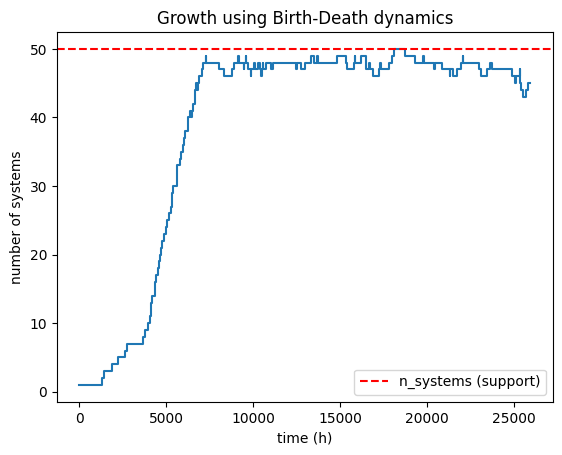

In [12]:
def gillespie_logistic(n0, r, K, T_max, death_rate):
    t = [0]
    n = [n0]
    
    current_n = n0
    current_t = 0
    
    while current_t < T_max and current_n > 0:
        # Taxas atuais
        birth_rate_n = r * current_n * (1-current_n/K)
        # death_rate_n = current_n*death_rate
        death_rate_n = current_n*death_rate
        total_rate = birth_rate_n + death_rate_n
        
        # 1. Tempo até o próximo evento (distribuição exponencial)
        dt = np.random.exponential(1 / total_rate)
        current_t += dt
        
        # 2. Qual evento ocorre?
        if np.random.rand() < (birth_rate_n / total_rate):
            current_n += 1  # Nascimento
        else:
            current_n -= 1  # Morte
            current_n = max(1, current_n)
            
        t.append(current_t)
        n.append(current_n)
        
    return np.array(t), np.array(n)

# Simulação
K = 50
t, n = gillespie_logistic(n0=1, r=0.001, K=K, T_max=3*12*30*24, death_rate=0.00005)

plt.step(t, n)
plt.axhline(K, color='red', linestyle='--', label='n_systems (support)')
plt.ylabel('number of systems')
plt.xlabel('time (h)')
plt.title('Growth using Birth-Death dynamics')
plt.legend()
plt.show()